In [1]:
! pip install seaborn

# universal semantic similarity

In [5]:
from absl import logging
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
import numpy as nlp
import os
import pandas as pd
import re
import seaborn as sns

module_url = "https://tfhub.dev/google/universal-sentence-encoder/4"
model = hub.load(module_url)
print("module %s loaded" % module_url)
def embed(input):
  return model(input)

module https://tfhub.dev/google/universal-sentence-encoder/4 loaded


In [7]:
from absl import logging
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import re
import seaborn as sns

In [8]:
word = "Elephant"
sentence = "The elephant is the largest land animal on Earth."
paragraph = "The elephant is the largest land animal on Earth. It has a trunk, tusks, and large ears. Elephants are known for their intelligence and strong social bonds."
messages = [word, sentence, paragraph]

#reduce logging output
logging.set_verbosity(logging.ERROR)

message_embeddings = embed(messages)

for i, message_embedding in enumerate(np.array(message_embeddings)):
  print("Message: {}".format(messages[i]))
  print("Embedding size: {}".format(len(message_embedding)))
  message_embedding_snipet = ", ".join((str(x) for x in message_embedding[:3]))
  print("Embedding: [{}, ...]\n".format(message_embedding_snipet))

Message: Elephant
Embedding size: 512
Embedding: [0.008344487, 0.0004808583, 0.06595248, ...]

Message: The elephant is the largest land animal on Earth.
Embedding size: 512
Embedding: [-0.039626, -0.05823745, 0.047235407, ...]

Message: The elephant is the largest land animal on Earth. It has a trunk, tusks, and large ears. Elephants are known for their intelligence and strong social bonds.
Embedding size: 512
Embedding: [-0.038592055, 0.021607533, 0.03558724, ...]



In [17]:
def plot_similarity(labels, features, rotation):
  corr = np.inner(features, features)
  sns.set(font_scale=1.2)
  g = sns.heatmap(
      corr,
      xticklabels=labels,
      yticklabels=labels,
      vmin=0,
      vmax=1,
      cmap="YlOrRd")
  g.set_xticklabels(labels, rotation=rotation)
  g.set_title("Semantic Similarity")
  plt.show()


def run_and_plot(messages):
  message_embeddings = embed(messages)
  plot_similarity(messages, message_embeddings, 90)

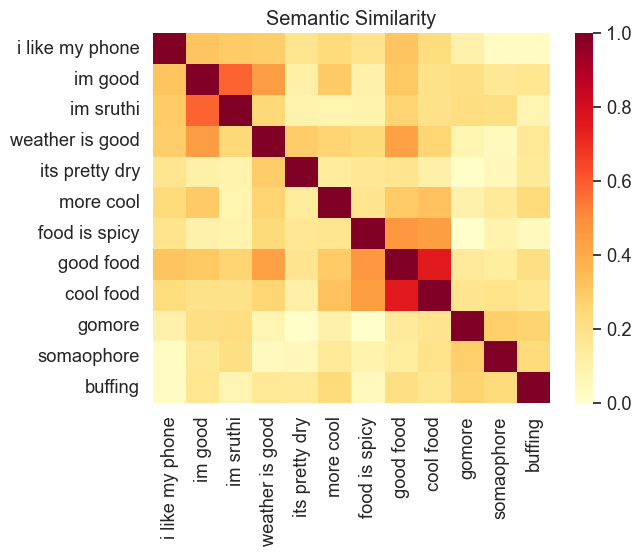

In [19]:
messages=[
    #smartphone
    "i like my phone",
    "im good",
    "im sruthi",

    #weather
    "weather is good",
    "its pretty dry",
    "more cool",

    #food
    "food is spicy",
    "good food",
    "cool food",
    #name
    "gomore",
    "somaophore",
    "buffing",
]

run_and_plot(messages)